In [1]:
#Importing packages
import argparse
import os
from torch.utils.data import DataLoader
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import pandas as pd
from chromadb import PersistentClient as PersistentClient
from chromadb.errors import InternalError as CollectionError
import random
import numpy as np

#library functions
import helper_code.dataloading as dataloading
import helper_code.data_vis as data_vis
import helper_code.model_functions as model_functions
import helper_code.loss_functions as loss_functions
import helper_code.models as models
from helper_code.seeds import set_seed


d:\Projects\alertcalifornia-anomaly-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
g = set_seed()

In [7]:
labels_csv = r"camera_data/coronado_hills_4pt.json"

device = 'cuda' 

data = dataloading.get_data_urls(labels_csv)
data.head()

,choice,image,annotation_id
0,-1,https://tools.alertcalifornia.org/fireframes5/...,NaN
1,-1,https://tools.alertcalifornia.org/fireframes5/...,NaN
2,2,https://tools.alertcalifornia.org/fireframes5/...,50377.0
3,-1,https://tools.alertcalifornia.org/fireframes5/...,NaN
4,-1,https://tools.alertcalifornia.org/fireframes5/...,NaN


In [5]:
labels_csv = r"camera_data/coronado_hills_4pt.json"

device = 'cuda' 

model_path = 'weights/'
model_name = "deepsad_init_model.pth"
    
data = dataloading.get_data(labels_csv, 'camera_data/images/', replace_images = False, binarize = False)

labeled_data = data[data['choice'] > -1]

full_train, _, _ = dataloading.get_train_val_test(data = data, output_csvs=False)

train, val, test = dataloading.get_train_val_test(data = labeled_data, output_csvs=True)

full_train_dataloader, _, _ = dataloading.get_train_val_test_dataloaders(full_train, val, test, generator = g)
train_dataloader, val_dataloader, test_dataloader = dataloading.get_train_val_test_dataloaders(train, val, test, generator = g)

  4%|▍         | 316/7488 [00:16<06:25, 18.62it/s]


KeyboardInterrupt: 

In [5]:
len(data)

2314

In [35]:
len(labeled_data)

2368

In [36]:
len(labeled_data['img_path'].unique())

2368

In [31]:
labeled_data['choice'].value_counts()

choice
1    966
0    578
3    421
2    403
Name: count, dtype: int64

In [32]:
labeled_data.head()

,choice,img_path,annotation_id,image,timestamp
2,2,camera_data/images/img_1081399.jpg,1081399,https://tools.alertcalifornia.org/fireframes5/...,1727773267
5,1,camera_data/images/img_1081402.jpg,1081402,https://tools.alertcalifornia.org/fireframes5/...,1727784125
11,0,camera_data/images/img_1081408.jpg,1081408,https://tools.alertcalifornia.org/fireframes5/...,1727805854
16,1,camera_data/images/img_1081413.jpg,1081413,https://tools.alertcalifornia.org/fireframes5/...,1727823936
17,1,camera_data/images/img_1081414.jpg,1081414,https://tools.alertcalifornia.org/fireframes5/...,1727827549


In [4]:
def run_model(lr, eta, weight_decay, num_epochs, head_num_epochs, head_lr, model_name):
    encoder = models.create_encoder()
    encoder.to(device)
    encoder.load_state_dict(torch.load('weights/model_weights_camera_10-27-25.pth', map_location=device, weights_only=True))

    loss_func = loss_functions.DeepSADLoss(model=encoder, train_data=train_dataloader, device = device, eta = eta)
    optimizer = optim.Adam(encoder.parameters(), lr=lr, weight_decay=weight_decay) 

    losses = model_functions.train_model(encoder, train_data=full_train_dataloader, 
                                num_epochs=num_epochs, loss_func=loss_func, 
                                optimizer=optimizer, name = model_name, path = 'weights/', device=device)
    

    client = PersistentClient(path="embedding_data/") 

    try:
        client.delete_collection(name="train_embeddings")
    except Exception:
        pass

    try:
        client.delete_collection(name="val_embeddings")
    except Exception:
        pass


    dataloading.save_full_embeddings(encoder, train_dataloader, 
                            "train_embeddings", persist_directory = "embedding_data/", 
                            device = device)


    dataloading.save_full_embeddings(encoder, val_dataloader, 
                            "val_embeddings", persist_directory = "embedding_data/", 
                            device = device)
        
    #Embeddings of training data, used to train the classification head
    train_embeddings, train_labels, _, _ = dataloading.load_full_embeddings(train, "train_embeddings", persist_directory = "embedding_data/")
    train_embedding_dataloader = dataloading.embedding_to_dataloader(train_embeddings, train_labels, batch_size=32, generator = g)

    val_embeddings, val_labels, _, _ = dataloading.load_full_embeddings(val, "val_embeddings", persist_directory = "embedding_data/")

    reduced_embeddings, labels = model_functions.reduce_pca(train_embeddings, train_labels, dimensions=4)

    classification_head = models.ClassificationHead(num_classes=2)
    classification_head.to(device)

    head_criterion = nn.CrossEntropyLoss()
    head_optimizer = optim.Adam(classification_head.parameters(), lr=head_lr) # Optimize only the new head

    losses = model_functions.train_classification_head(classification_head, train_embedding_dataloader, num_epochs=head_num_epochs, criterion=head_criterion, optimizer=head_optimizer, 
                                                       device=device, model_name=model_name, model_path = "weights/")

    train_accuracy = model_functions.get_classification_accuracy(train_embeddings, train_labels, classification_head, device)
    val_accuracy = model_functions.get_classification_accuracy(val_embeddings, val_labels, classification_head, device)


    return losses, reduced_embeddings, labels, train_accuracy, val_accuracy

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Processing batch 140 in epoch 0: : 141it [01:57,  1.20it/s]
Processing batch 140 in epoch 1: : 141it [01:58,  1.19it/s]
Processing batch 140 in epoch 2: : 141it [01:57,  1.20it/s]
Processing batch 140 in epoch 3: : 141it [02:00,  1.17it/s]
Processing batch 140 in epoch 4: : 141it [01:55,  1.22it/s]
Processing batches in epoch 4: 100%|██████████| 45/45 [00:03<00:00, 12.59it/s]
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Processing batch 140 in epoch 0: : 141it [01:55, 

Displaying losses...



C:\Users\Aneesh\AppData\Local\Temp\ipykernel_36320\698693272.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_losses.show()


Train Accuracy Val Accuracy
Eta   Learning Rate Weight Decay                            
0.01  0.000100      1.000000e-05       0.794366     0.799578
                    1.000000e-06       0.827465     0.837553
                    1.000000e-07        0.79507     0.799578
      0.000010      1.000000e-05       0.861268     0.869198
                    1.000000e-06       0.871831     0.879747
                    1.000000e-07       0.865493     0.875527
      0.000001      1.000000e-05       0.864789     0.869198
                    1.000000e-06       0.869718     0.869198
                    1.000000e-07       0.859155     0.871308
0.10  0.000100      1.000000e-05       0.742958     0.738397
                    1.000000e-06       0.789437       0.7827
                    1.000000e-07       0.769014     0.778481
      0.000010      1.000000e-05       0.882394     0.881857
                    1.000000e-06       0.885915     0.886076
                    1.000000e-07       0.883099     0.883966
      0.000001      1.000000e-05       0.858451      0.85443
                    1.000000e-06       0.857042     0.869198
                    1.000000e-07       0.880986     0.883966
1.00  0.000100      1.000000e-05        0.75493     0.761603
                    1.000000e-06       0.812676     0.818565
                    1.000000e-07       0.809859     0.808017
      0.000010      1.000000e-05       0.875352     0.879747
                    1.000000e-06       0.876056     0.886076
                    1.000000e-07       0.874648     0.888186
      0.000001      1.000000e-05       0.880282     0.886076
                    1.000000e-06       0.856338     0.864979
                    1.000000e-07        0.88662     0.879747
10.00 0.000100      1.000000e-05       0.807746     0.822785
                    1.000000e-06       0.751408     0.746835
                    1.000000e-07       0.790141     0.799578
      0.000010      1.000000e-05       0.866901     0.871308
                    1.000000e-06       0.859859     0.867089
                    1.000000e-07       0.883099     0.883966
      0.000001      1.000000e-05       0.858451     0.867089
                    1.000000e-06       0.872535     0.864979
                    1.000000e-07       0.876056     0.892405

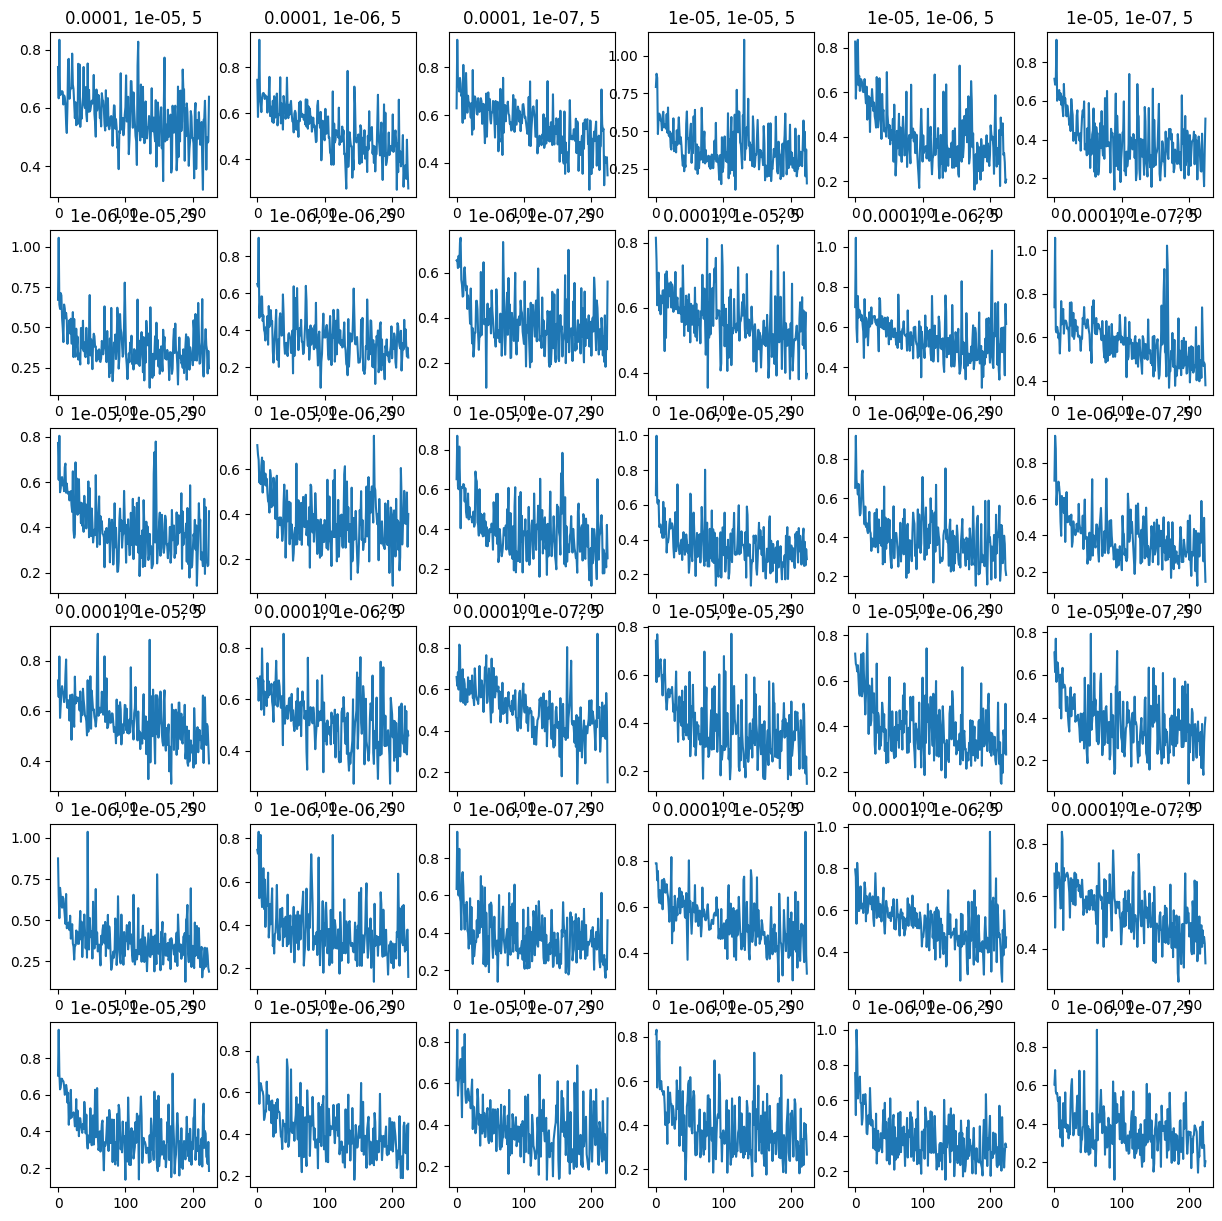

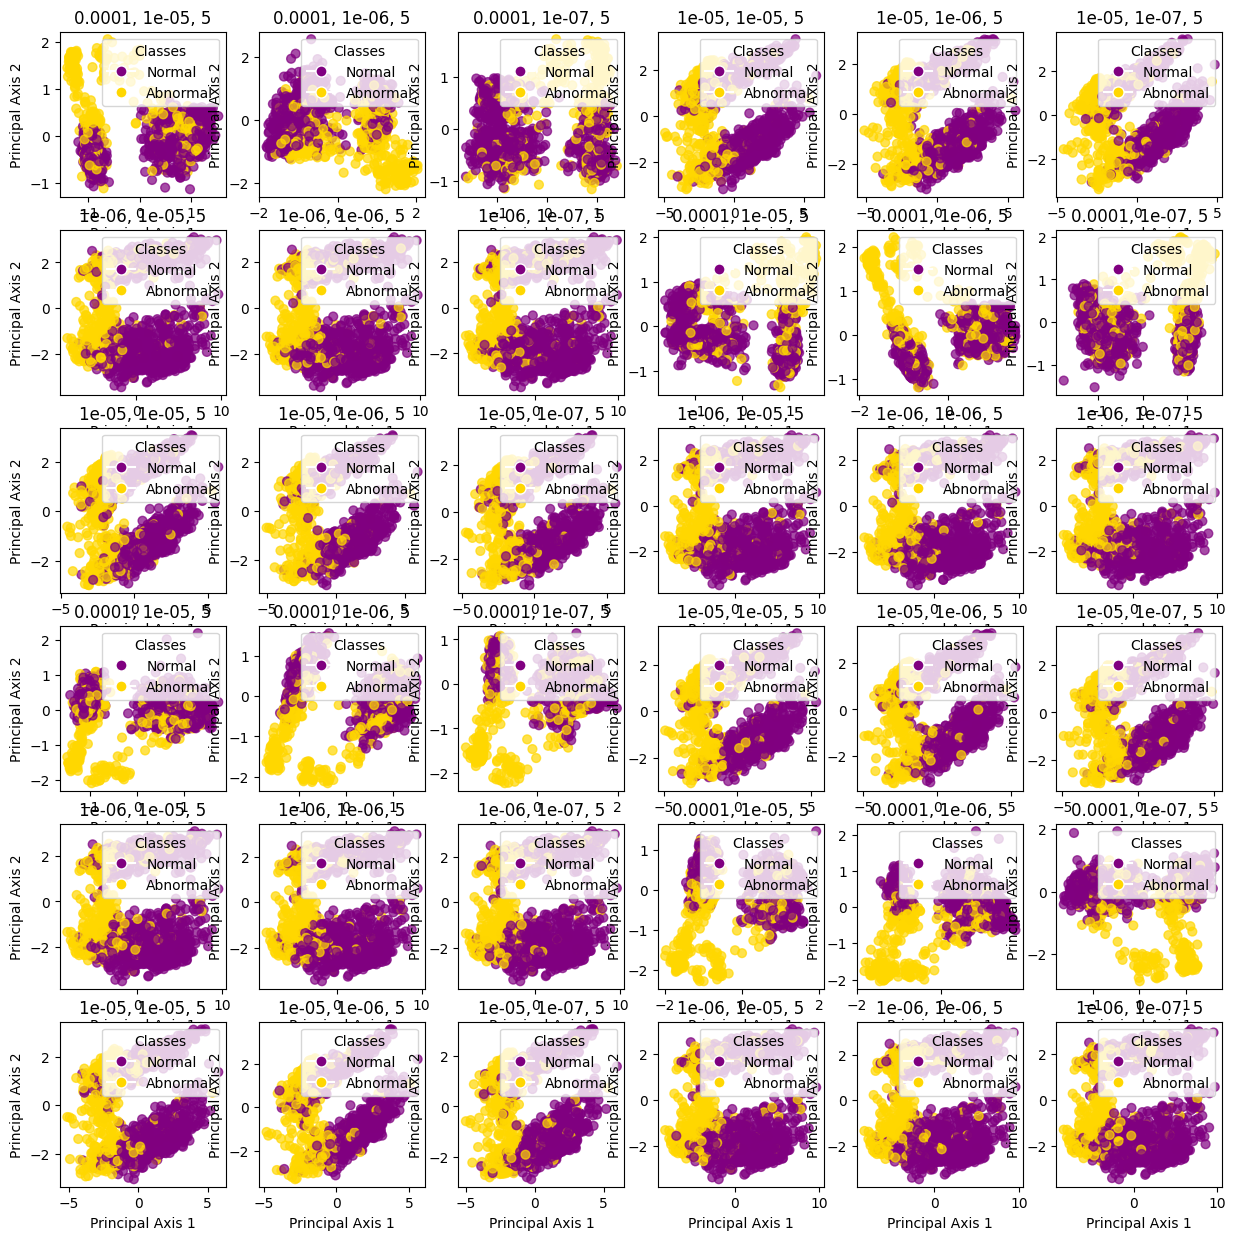

In [5]:
from itertools import product
import matplotlib.pyplot as plt

alpha = 0
etas = [0.01, 0.1, 1, 10]
lrs = [1e-4, 1e-5, 1e-6]
weight_decay = [1e-5, 1e-6, 1e-7]
num_epochs = 5
head_num_epochs = 5
head_lr = 1e-3

combinations = list(product(etas, lrs, weight_decay))

accuracies_df = pd.DataFrame(index = pd.MultiIndex.from_tuples(combinations, 
                                                               names = ["Eta", "Learning Rate", "Weight Decay"]), 
                                                               columns = ["Train Accuracy", "Val Accuracy"])


fig_losses, ax_losses = plt.subplots(6, 6, figsize=(15, 15))
fig_embeddings, ax_embeddings = plt.subplots(6, 6, figsize=(15, 15))
for i, (eta, lr, weight_decay) in enumerate(combinations):
    losses, reduced_embeddings, labels, train_accuracy, val_accuracy = run_model(lr, eta, weight_decay, 
                                                                                 num_epochs, head_num_epochs, head_lr,
                                                                                   model_name=model_name)

    ax_losses[i//6, i%6].plot(list(range(len(losses))), losses)
    ax_losses[i//6, i%6].set_title(f"{lr}, {weight_decay}, {num_epochs}")

    ax_embeddings[i//6, i%6] = data_vis.plot_data(reduced_embeddings, labels,
                                                  ax=ax_embeddings[i//6, i%6], 
                                                  title=f"{lr}, {weight_decay}, {num_epochs}")
    

    accuracies_df.loc[(eta, lr, weight_decay), "Train Accuracy"] = train_accuracy
    accuracies_df.loc[(eta, lr, weight_decay), "Val Accuracy"] = val_accuracy


print("Displaying losses...")
fig_losses.show()
#print("Displaying embeddings...")
#fig_embeddings.show()

accuracies_df

Instantiating the pre-trained model

In [6]:
accuracies_df

Train Accuracy Val Accuracy
Eta   Learning Rate Weight Decay                            
0.01  0.000100      1.000000e-05       0.794366     0.799578
                    1.000000e-06       0.827465     0.837553
                    1.000000e-07        0.79507     0.799578
      0.000010      1.000000e-05       0.861268     0.869198
                    1.000000e-06       0.871831     0.879747
                    1.000000e-07       0.865493     0.875527
      0.000001      1.000000e-05       0.864789     0.869198
                    1.000000e-06       0.869718     0.869198
                    1.000000e-07       0.859155     0.871308
0.10  0.000100      1.000000e-05       0.742958     0.738397
                    1.000000e-06       0.789437       0.7827
                    1.000000e-07       0.769014     0.778481
      0.000010      1.000000e-05       0.882394     0.881857
                    1.000000e-06       0.885915     0.886076
                    1.000000e-07       0.883099     0.883966
      0.000001      1.000000e-05       0.858451      0.85443
                    1.000000e-06       0.857042     0.869198
                    1.000000e-07       0.880986     0.883966
1.00  0.000100      1.000000e-05        0.75493     0.761603
                    1.000000e-06       0.812676     0.818565
                    1.000000e-07       0.809859     0.808017
      0.000010      1.000000e-05       0.875352     0.879747
                    1.000000e-06       0.876056     0.886076
                    1.000000e-07       0.874648     0.888186
      0.000001      1.000000e-05       0.880282     0.886076
                    1.000000e-06       0.856338     0.864979
                    1.000000e-07        0.88662     0.879747
10.00 0.000100      1.000000e-05       0.807746     0.822785
                    1.000000e-06       0.751408     0.746835
                    1.000000e-07       0.790141     0.799578
      0.000010      1.000000e-05       0.866901     0.871308
                    1.000000e-06       0.859859     0.867089
                    1.000000e-07       0.883099     0.883966
      0.000001      1.000000e-05       0.858451     0.867089
                    1.000000e-06       0.872535     0.864979
                    1.000000e-07       0.876056     0.892405

In [10]:
encoder = models.create_encoder()
encoder.to(device)
encoder.load_state_dict(torch.load('weights/model_weights_camera_10-27-25.pth', map_location=device, weights_only=True));

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Instantiating the training settings

In [11]:
loss_func = loss_functions.DeepSADLoss(model=encoder, train_data=train_dataloader, device = device, eta = 10)
optimizer = optim.Adam(encoder.parameters(), lr=1e-6, weight_decay=1e-7) 
num_epochs = 1

Training the model

In [12]:
losses = model_functions.train_model(encoder, train_data=full_train_dataloader, 
                                num_epochs=num_epochs, loss_func=loss_func, 
                                optimizer=optimizer, name = 'sad_loss_model.pth', path = 'weights/', device=device)

Processing batch 140 in epoch 0: : 141it [03:13,  1.37s/it]


Text(0.5, 1.0, 'Image to Embeddings Model Losses')

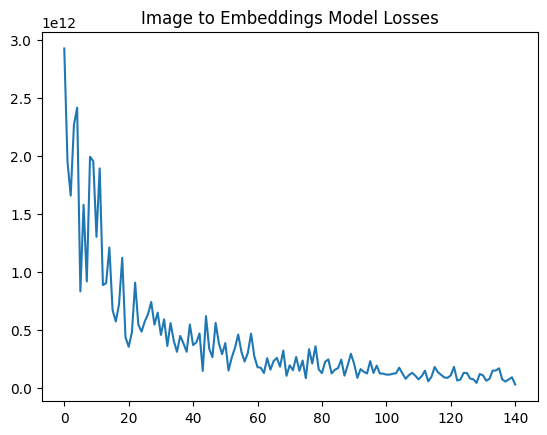

In [13]:
import matplotlib.pyplot as plt

plt.plot(list(range(len(losses))), losses)
plt.title("Image to Embeddings Model Losses")

Saving the embeddings generated by this model

In [14]:
client = PersistentClient(path="embedding_data/") 

try:
    client.delete_collection(name="train_embeddings")
except Exception:
    pass

try:
    client.delete_collection(name="val_embeddings")
except Exception:
    pass


dataloading.save_full_embeddings(encoder, train_dataloader, 
                        "train_embeddings", persist_directory = "embedding_data/", 
                        device = device)


dataloading.save_full_embeddings(encoder, val_dataloader, 
                        "val_embeddings", persist_directory = "embedding_data/", 
                        device = device)
    
    
#Embeddings of training data, used to train the classification head
train_embeddings, train_labels, _, _ = dataloading.load_full_embeddings(train, "train_embeddings", persist_directory = "embedding_data/")
train_embedding_dataloader = dataloading.embedding_to_dataloader(train_embeddings, train_labels, batch_size=32, generator = g)

#Embeddings of validation data, used to display results
val_embeddings, val_labels, _, _ = dataloading.load_full_embeddings(val, "val_embeddings", persist_directory = "embedding_data/")

Visualizing the first two principal axes of the embedding space

In [15]:
reduced_embeddings, labels = model_functions.reduce_pca(train_embeddings, train_labels, dimensions=4)

Text(0.5, 1.0, 'First two axes of embedding space')

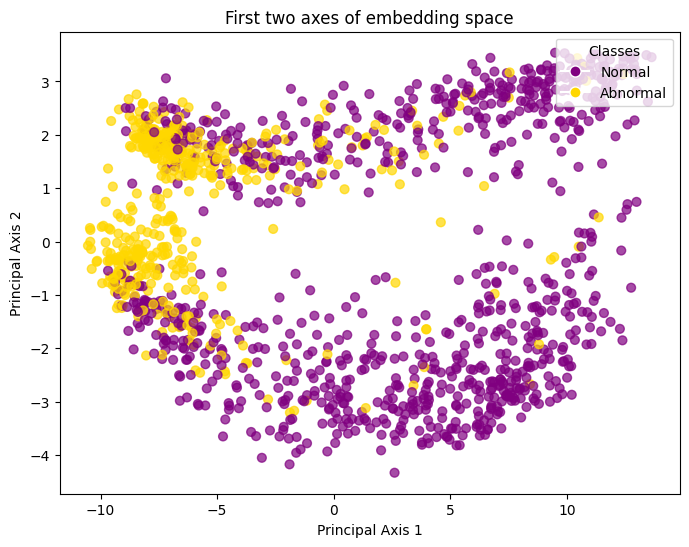

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax = data_vis.plot_data(reduced_embeddings, labels, pcx = 1, pcy = 2, ax=ax)
ax.set_title("First two axes of embedding space")

Training classification head

In [18]:
losses = []

classification_head = models.ClassificationHead(num_classes=2)
classification_head.to(device)

head_criterion = nn.CrossEntropyLoss()
head_optimizer = optim.Adam(classification_head.parameters(), lr=1e-3) # Optimize only the new head

losses = model_functions.train_classification_head(classification_head, train_embedding_dataloader, num_epochs=10, criterion=head_criterion, optimizer=head_optimizer, 
                           device=device, model_name=model_name, model_path = "weights/", save=True)

#Report training and validation accuracy
classification_head.eval()

Processing batches in epoch 9: 100%|██████████| 45/45 [00:03<00:00, 11.27it/s]


ClassificationHead(
  (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

Testing classification head outputs

In [19]:
train_embeddings_tensor = torch.Tensor(train_embeddings.to_numpy()).to(device)
val_embeddings_tensor = torch.Tensor(val_embeddings.to_numpy()).to(device)

train_labels_tensor = torch.Tensor(train_labels.to_numpy()).to(device)
val_labels_tensor = torch.Tensor(val_labels.to_numpy()).to(device)


train_outputs = classification_head(train_embeddings_tensor)
val_outputs = classification_head(val_embeddings_tensor)

print(f"Training accuracy: {(torch.argmax(train_outputs, dim = -1) == train_labels_tensor).float().mean().item()}")
print(f"Validation accuracy: {(torch.argmax(val_outputs, dim = -1) == val_labels_tensor).float().mean().item()}")

Training accuracy: 0.8943661451339722
Validation accuracy: 0.905063271522522


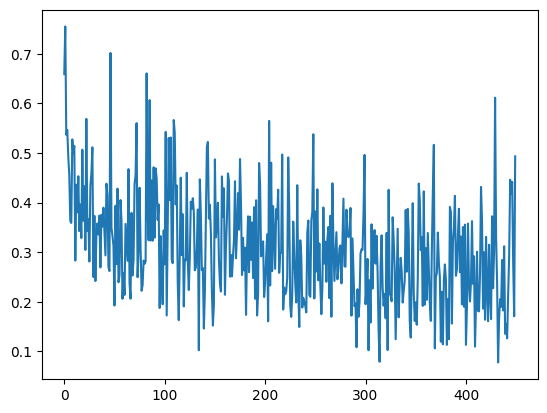

In [20]:
plt.plot(list(range(len(losses))), losses)